## Topic Modelling (Part 1)

This notebook uses BERTopic on all the virws to do topic modeling of cleaned customer reviews so as to identify common themes (topics) addressed in the text and evaluate their relationship with customer ratings. In particular, we look to:

1. Find out the most and least discussed topics in the dataset.
2. Check how these topics are rated based on average star ratings.
3. Check if topics witnessed often are also highly rated (or poorly rated).
4. Evaluate the distribution of average star ratings over topics

---

5. Visualize the presence and influence of each topic by adapting interpretable top-word labels.

Import relevant packages.

In [1]:
import pandas as pd
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Have a stopwords list
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Connect to google drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Use the dataset for reviews obtained the final_df produced in the file where we did the EDA analysis.

In [3]:
reviews = pd.read_csv('/content/drive/MyDrive/BUDT758/final_df_raw.csv')
reviews

,index,business_id,name,address,city,state,postal_code,latitude,longitude,stars,...,happy_hour,has_parking,GEO_ID,review_id,user_id,useful,funny,cool,text,date
0,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,True,True,4.210100e+14,XYaDbPKyJAu4k2aUOIth5g,Qsk0aTclam9W_DIK6bx42A,0,0,0,Stopped in to check out this new spot around t...,2017-12-16 00:13:06
1,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,True,True,4.210100e+14,tpLolBuBTx_Ncx3RSf7WBw,TJW1aEzjhaxbD10fjhokfQ,0,0,0,I live in the neighborhood and used to order a...,2018-04-28 00:46:05
2,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,True,True,4.210100e+14,u0mLU6WALXLsCM8sNtGxlw,PYaXWwacBhNPVtXEZ1j-_w,1,0,0,We came here tonight just for a date night. We...,2018-01-10 02:56:31
3,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,True,True,4.210100e+14,R5Ha2XF3zevW0D3D6J1d2w,T9b7lYhNTAr7PyL4x8mmIw,0,0,0,Wow! What a great dining adventure! Huge rolls...,2017-12-29 23:57:16
4,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,True,True,4.210100e+14,6PywmKFi6ma5GfEykq0suw,HkUkwpQRNsigIYoALJjczg,0,0,0,"Wonderfully fresh sushi, amazing lobster fried...",2018-01-22 01:47:25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209796,14313,vhE94NRER_4utAtbryLOiQ,Mermaid Inn,7673 Germantown Ave,Philadelphia,PA,19118,40.067949,-75.196798,3.5,...,NaN,False,4.210103e+14,t4MoErWhXn3D1LBBnEHlsw,7huCGwcfhkVu0kn5wFSwbQ,2,0,1,Wow \nI love this place!!!\nIt's historic and ...,2018-06-17 19:32:49
209797,14313,vhE94NRER_4utAtbryLOiQ,Mermaid Inn,7673 Germantown Ave,Philadelphia,PA,19118,40.067949,-75.196798,3.5,...,NaN,False,4.210103e+14,79cLHX94uzXv2GWd7OHOTw,myXQ8V5vvvcH9JblKh6GvQ,9,0,0,Such a shame. I had a really great experience ...,2016-04-05 19:17:31
209798,14313,vhE94NRER_4utAtbryLOiQ,Mermaid Inn,7673 Germantown Ave,Philadelphia,PA,19118,40.067949,-75.196798,3.5,...,NaN,False,4.210103e+14,Nyt0xOR03wFl4t1DR0zexw,4jqSryBOZsomgAUh29EZ5Q,0,0,0,You don't go here for gourmet food or exciting...,2021-10-25 18:07:40
209799,14313,vhE94NRER_4utAtbryLOiQ,Mermaid Inn,7673 Germantown Ave,Philadelphia,PA,19118,40.067949,-75.196798,3.5,...,NaN,False,4.210103e+14,hsYPPyqPxyoaSZVwwZJ7mQ,T5QUqd50NUXe10rX8BEFDQ,0,0,0,"I come up here, to this venue, just a handful ...",2011-09-03 03:18:08


Briefly preview how reviews appear in the dataframe.

In [4]:
reviews[['name', 'text']].head()

,name,text
0,Tuna Bar,Stopped in to check out this new spot around t...
1,Tuna Bar,I live in the neighborhood and used to order a...
2,Tuna Bar,We came here tonight just for a date night. We...
3,Tuna Bar,Wow! What a great dining adventure! Huge rolls...
4,Tuna Bar,"Wonderfully fresh sushi, amazing lobster fried..."


For preparing the reviews for topic modeling, I created a `clean_review()` function that preprocesses the text by taking out non-alphabetical characters, changing all text to lowercase, and splitting it into individual tokens. It then filters out usual stop words and any words that are less than three characters. The cleaned tokens are joined back into a single string and kept in a new column named `cleaned_review`. This will be utlilized as input for topic modeling.

In [5]:
def clean_review(text):
    if pd.isnull(text):
        return ''
    else:
        only_letter_text = re.sub(r"[^a-zA-Z]", " ", text)
        only_letter_text = only_letter_text.lower()
        token_values = only_letter_text.split()
        token_values = [word for word in token_values if word not in stop_words and len(word) > 2]
        return " ".join(token_values)

# Apply to plain text column
reviews['cleaned_review'] = reviews['text'].apply(clean_review)

Install bertopic to do topic modelling.

In [6]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 108.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninst

Use BERTopic on the `cleaned_review` column to find out underlying topics amongst the reviews. Every review is first converted into a list format and then given to the `fit_transform()` function to identify topic assignments and the corresponding probabilities.

In [7]:
from bertopic import BERTopic

docs = reviews['cleaned_review'].tolist()
topic_model = BERTopic()
topics, probs = topic_model.fit_transform(docs)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Store topics obtained back into the dataframe.

In [8]:
# Have topics back in the DataFrame
reviews['topic'] = topics

In [9]:
reviews

,index,business_id,name,address,city,state,postal_code,latitude,longitude,stars,...,GEO_ID,review_id,user_id,useful,funny,cool,text,date,cleaned_review,topic
0,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,4.210100e+14,XYaDbPKyJAu4k2aUOIth5g,Qsk0aTclam9W_DIK6bx42A,0,0,0,Stopped in to check out this new spot around t...,2017-12-16 00:13:06,stopped check new spot around corner boyfriend...,12
1,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,4.210100e+14,tpLolBuBTx_Ncx3RSf7WBw,TJW1aEzjhaxbD10fjhokfQ,0,0,0,I live in the neighborhood and used to order a...,2018-04-28 00:46:05,live neighborhood used order least week pick l...,52
2,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,4.210100e+14,u0mLU6WALXLsCM8sNtGxlw,PYaXWwacBhNPVtXEZ1j-_w,1,0,0,We came here tonight just for a date night. We...,2018-01-10 02:56:31,came tonight date night started basics edamame...,-1
3,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,4.210100e+14,R5Ha2XF3zevW0D3D6J1d2w,T9b7lYhNTAr7PyL4x8mmIw,0,0,0,Wow! What a great dining adventure! Huge rolls...,2017-12-29 23:57:16,wow great dining adventure huge rolls good sak...,201
4,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,4.210100e+14,6PywmKFi6ma5GfEykq0suw,HkUkwpQRNsigIYoALJjczg,0,0,0,"Wonderfully fresh sushi, amazing lobster fried...",2018-01-22 01:47:25,wonderfully fresh sushi amazing lobster fried ...,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209796,14313,vhE94NRER_4utAtbryLOiQ,Mermaid Inn,7673 Germantown Ave,Philadelphia,PA,19118,40.067949,-75.196798,3.5,...,4.210103e+14,t4MoErWhXn3D1LBBnEHlsw,7huCGwcfhkVu0kn5wFSwbQ,2,0,1,Wow \nI love this place!!!\nIt's historic and ...,2018-06-17 19:32:49,wow love place historic ton ambiance stone con...,-1
209797,14313,vhE94NRER_4utAtbryLOiQ,Mermaid Inn,7673 Germantown Ave,Philadelphia,PA,19118,40.067949,-75.196798,3.5,...,4.210103e+14,79cLHX94uzXv2GWd7OHOTw,myXQ8V5vvvcH9JblKh6GvQ,9,0,0,Such a shame. I had a really great experience ...,2016-04-05 19:17:31,shame really great experience months back past...,-1
209798,14313,vhE94NRER_4utAtbryLOiQ,Mermaid Inn,7673 Germantown Ave,Philadelphia,PA,19118,40.067949,-75.196798,3.5,...,4.210103e+14,Nyt0xOR03wFl4t1DR0zexw,4jqSryBOZsomgAUh29EZ5Q,0,0,0,You don't go here for gourmet food or exciting...,2021-10-25 18:07:40,gourmet food exciting original cocktails best ...,-1
209799,14313,vhE94NRER_4utAtbryLOiQ,Mermaid Inn,7673 Germantown Ave,Philadelphia,PA,19118,40.067949,-75.196798,3.5,...,4.210103e+14,hsYPPyqPxyoaSZVwwZJ7mQ,T5QUqd50NUXe10rX8BEFDQ,0,0,0,"I come up here, to this venue, just a handful ...",2011-09-03 03:18:08,come venue handful times year hear one favorit...,6


The table below provides a summary of the topics created by BERTopic using the `get_topic_info()` function. Every row shows a topic identified from the reviews, as well as the number of documents assigned to it (`Count`), a keyword-based topic name (`Name`), the most representative keywords (`Representation`), and an example review (`Representative_Docs`) that best describes the topic. Topic `-1` is a reference to outlier documents that could not be directed to a meaningful topic. This result provides a good overview of the dominant themes in the dataset and assists in analyzing what each topic represents.

In [10]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,129398,-1_bar_place_food_good,"[bar, place, food, good, great, drinks, servic...",[looking nice place catch enjoy brunch came ac...
1,0,4739,0_cheesesteak_jim_cheesesteaks_whiz,"[cheesesteak, jim, cheesesteaks, whiz, steak, ...",[jim looking quick well really dirty philly ch...
2,1,2712,1_table_dish_asked_dessert,"[table, dish, asked, dessert, server, said, br...",[really sad report restaurant week review typi...
3,2,2488,2_atmosphere_service_food_staff,"[atmosphere, service, food, staff, excellent, ...",[got chef tasting absolutely outstanding fabul...
4,3,2148,3_pizza_crust_pizzas_pie,"[pizza, crust, pizzas, pie, beddia, pies, pizz...",[fantastic service large pizza pie coworker ev...
...,...,...,...,...,...
667,666,10,666_school_sunday_tria_bruschetta,"[school, sunday, tria, bruschetta, wines, pica...",[enjoy sunday school sure check tria sunday gr...
668,667,10,667_knowledgeabley_walkabout_elderflowers_mnyk,"[knowledgeabley, walkabout, elderflowers, mnyk...",[tried place first time last week came friends...
669,668,10,668_guyou_blast_bozo_nickname,"[guyou, blast, bozo, nickname, atmospheres, ca...",[good atmosphere nights wednesdays great cheap...
670,669,10,669_obsessedddddd_vendors_pensive_weekends,"[obsessedddddd, vendors, pensive, weekends, fo...",[many times great place large groups large var...


Take a closer look at a sample output showing the top-ranked words associated with a certain topic. Every word is assocuated with a relevance score suggesting how strongly it represents the topic.

In [11]:
topic_model.get_topic(0)

[('cheesesteak', np.float64(0.027032568125613794)),
 ('jim', np.float64(0.01989657560430203)),
 ('cheesesteaks', np.float64(0.014885010715269835)),
 ('whiz', np.float64(0.014129106075813056)),
 ('steak', np.float64(0.011325089039750175)),
 ('steaks', np.float64(0.010863952067940746)),
 ('onions', np.float64(0.010552764705910891)),
 ('geno', np.float64(0.00984165412458643)),
 ('pat', np.float64(0.009808988645670045)),
 ('line', np.float64(0.009596010002738652))]

To encourage interpretability, the following code block performs an extraction for the top 5 most representative words for every topic using the `get_topic()` method. These words are ranked according to their relevance scores and reflect the important themes linked to each topic. A helper function (`obtain_top_words`) is adapted to obtain and format the top words into a comma-separated string.

Another column, `top_words`, is then created in the DataFrame. It assigns a descriptive label to every review based on its topic. This makes it simpler to evaluate and visualize topics in a more user-friendly format.


In [12]:
# Obtain top words for every topic
topic_information = topic_model.get_topic_info()
topic_word_values = {
    row['Topic']: topic_model.get_topic(row['Topic'])
    for _, row in topic_information.iterrows() if row['Topic'] != -1
}

# Change list of tuples to have only top words (e.g., 'food', 'sushi', etc.)
def obtain_top_words(topic_id):
    if topic_id in topic_word_values:
        return ", ".join([word for word, _ in topic_word_values[topic_id][:5]])
    else:
        return "N/A"

reviews['top_words'] = reviews['topic'].apply(obtain_top_words)

In [13]:
reviews

,index,business_id,name,address,city,state,postal_code,latitude,longitude,stars,...,review_id,user_id,useful,funny,cool,text,date,cleaned_review,topic,top_words
0,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,XYaDbPKyJAu4k2aUOIth5g,Qsk0aTclam9W_DIK6bx42A,0,0,0,Stopped in to check out this new spot around t...,2017-12-16 00:13:06,stopped check new spot around corner boyfriend...,12,"sushi, byob, fresh, quality, byo"
1,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,tpLolBuBTx_Ncx3RSf7WBw,TJW1aEzjhaxbD10fjhokfQ,0,0,0,I live in the neighborhood and used to order a...,2018-04-28 00:46:05,live neighborhood used order least week pick l...,52,"delivery, called, order, phone, driver"
2,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,u0mLU6WALXLsCM8sNtGxlw,PYaXWwacBhNPVtXEZ1j-_w,1,0,0,We came here tonight just for a date night. We...,2018-01-10 02:56:31,came tonight date night started basics edamame...,-1,N/A
3,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,R5Ha2XF3zevW0D3D6J1d2w,T9b7lYhNTAr7PyL4x8mmIw,0,0,0,Wow! What a great dining adventure! Huge rolls...,2017-12-29 23:57:16,wow great dining adventure huge rolls good sak...,201,"tea, scones, afternoon, sandwiches, tier"
4,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,6PywmKFi6ma5GfEykq0suw,HkUkwpQRNsigIYoALJjczg,0,0,0,"Wonderfully fresh sushi, amazing lobster fried...",2018-01-22 01:47:25,wonderfully fresh sushi amazing lobster fried ...,-1,N/A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209796,14313,vhE94NRER_4utAtbryLOiQ,Mermaid Inn,7673 Germantown Ave,Philadelphia,PA,19118,40.067949,-75.196798,3.5,...,t4MoErWhXn3D1LBBnEHlsw,7huCGwcfhkVu0kn5wFSwbQ,2,0,1,Wow \nI love this place!!!\nIt's historic and ...,2018-06-17 19:32:49,wow love place historic ton ambiance stone con...,-1,N/A
209797,14313,vhE94NRER_4utAtbryLOiQ,Mermaid Inn,7673 Germantown Ave,Philadelphia,PA,19118,40.067949,-75.196798,3.5,...,79cLHX94uzXv2GWd7OHOTw,myXQ8V5vvvcH9JblKh6GvQ,9,0,0,Such a shame. I had a really great experience ...,2016-04-05 19:17:31,shame really great experience months back past...,-1,N/A
209798,14313,vhE94NRER_4utAtbryLOiQ,Mermaid Inn,7673 Germantown Ave,Philadelphia,PA,19118,40.067949,-75.196798,3.5,...,Nyt0xOR03wFl4t1DR0zexw,4jqSryBOZsomgAUh29EZ5Q,0,0,0,You don't go here for gourmet food or exciting...,2021-10-25 18:07:40,gourmet food exciting original cocktails best ...,-1,N/A
209799,14313,vhE94NRER_4utAtbryLOiQ,Mermaid Inn,7673 Germantown Ave,Philadelphia,PA,19118,40.067949,-75.196798,3.5,...,hsYPPyqPxyoaSZVwwZJ7mQ,T5QUqd50NUXe10rX8BEFDQ,0,0,0,"I come up here, to this venue, just a handful ...",2011-09-03 03:18:08,come venue handful times year hear one favorit...,6,"dance, venue, music, dancing, stage"


In [14]:
# Export first 15 rows to CSV for checking
reviews.head(15).to_csv('first_15_rows.csv', index=False)

Given that we have the data frame with our topics, we will start making visualizations to analyze their distribution and relevance. Reviews allocated to topic `-1` are seen as outliers by BERTopic and are not in any meaningful cluster. Hence, these rows would be taken out from the analysis to make sure the visualizations account only for interpretable and coherent topics.

In [15]:
filtered_df = reviews[reviews['topic'] != -1]

Show the 15 most frequently occurring topics according to the count of assigned reviews.

In [16]:
filtered_df['topic'].value_counts().head(15)

,count
topic,
0,4739
1,2712
2,2488
3,2148
4,1902
5,1838
6,1762
7,1732
8,1372


In [17]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80403 entries, 0 to 209799
Data columns (total 46 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            80403 non-null  int64  
 1   business_id      80403 non-null  object 
 2   name             80403 non-null  object 
 3   address          80400 non-null  object 
 4   city             80403 non-null  object 
 5   state            80403 non-null  object 
 6   postal_code      80403 non-null  int64  
 7   latitude         80403 non-null  float64
 8   longitude        80403 non-null  float64
 9   stars            80403 non-null  float64
 10  review_count     80403 non-null  int64  
 11  is_open          80403 non-null  int64  
 12  attributes       80387 non-null  object 
 13  categories       80403 non-null  object 
 14  hours            79152 non-null  object 
 15  accepts_cards    79771 non-null  object 
 16  take_out         68827 non-null  object 
 17  delivery        

Show a graph the top 15 most frequently occurring topics, labeled by their top 5 representative words, to find out the dominant themes present in the reviews.

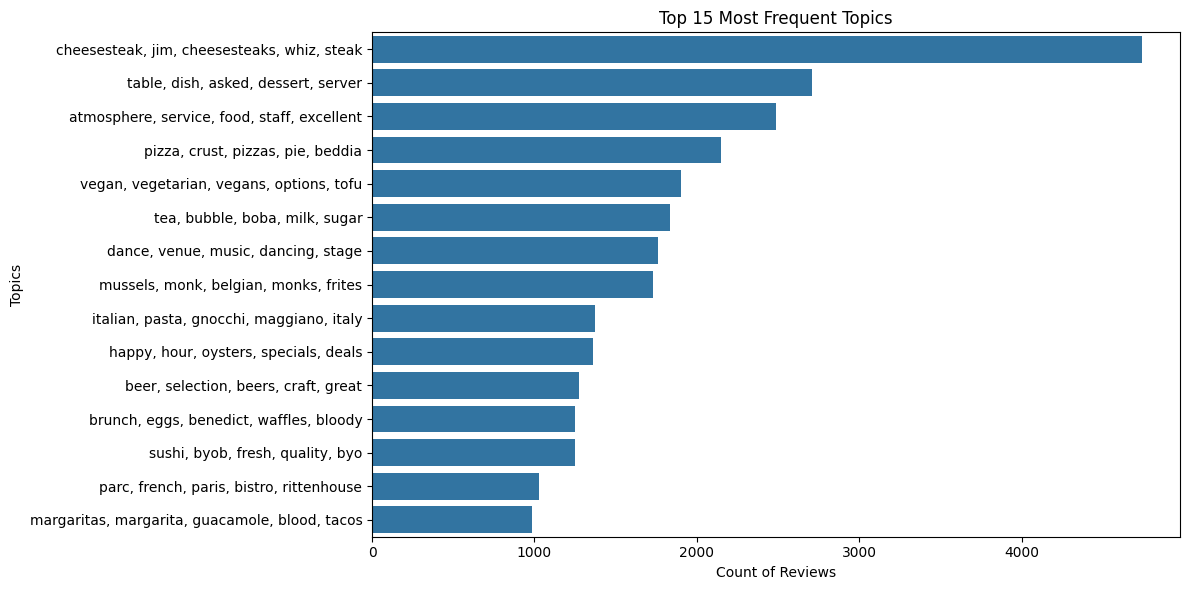

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 15 most frequent topics
top_15_freq = filtered_df['topic'].value_counts().head(15)

# Make use of top_words mapping from filtered_df
topic_labels = filtered_df.drop_duplicates('topic').set_index('topic')['top_words'].to_dict()

# Rename topic IDs to their top-word labels
top_15_freq_named = top_15_freq.rename(index=topic_labels)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_15_freq_named.values, y=top_15_freq_named.index)
plt.title("Top 15 Most Frequent Topics")
plt.xlabel("Count of Reviews")
plt.ylabel("Topics")
plt.tight_layout()
plt.show()

The graph visualizes the top 15 most frequent topics from a filtered review dataset by using both bar and line charts. Through making use of groupby, the code aggregates key metrics—count of topic mentions, average star ratings, and top words—before selecting the top 15 topics by count. A dual-axis chart is ceated. The bar chart (left y-axis) shows the count of reviews for every topic in grey, while a line chart (right y-axis) overlays the average rating in blue with circular markers. The x-axis shows the topic keywords, rotated at 45 degrees for readability. The output visualization assists with finding out which popular topics are also highly rated, providing insight into both volume and quality of reviews.

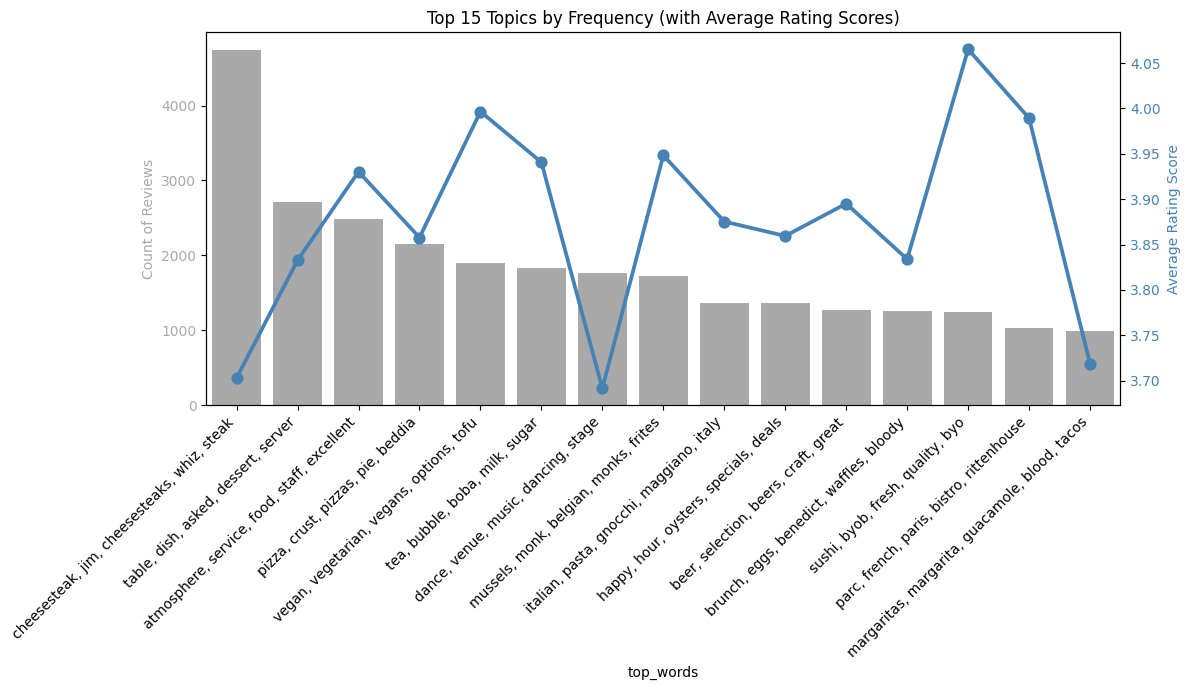

In [52]:
# Group topics
topic_grouped = filtered_df.groupby('topic').agg(
    count=('topic', 'count'),
    avg_rating=('stars', 'mean'),
    top_words=('top_words', 'first')
).reset_index()

# Obtain top 15 topics based on frequency
top_topic_values = topic_grouped.sort_values(by='count', ascending=False).head(15)

# Plot rating and topic on same chart
fig, ax1 = plt.subplots(figsize=(12,7))
sns.barplot(x='top_words', y='count', data=top_topic_values, ax=ax1, color='darkgray')
ax1.set_ylabel('Count of Reviews', color='darkgray')
ax1.tick_params(axis='y', labelcolor='darkgray')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Add a second y-axis to track star ratings
ax2 = ax1.twinx()
sns.pointplot(x='top_words', y='avg_rating', data=top_topic_values, ax=ax2, color='steelblue', markers='o')
ax2.set_ylabel('Average Rating Score', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')
plt.title("Top 15 Topics by Frequency (with Average Rating Scores)")
plt.tight_layout()
plt.show()

The visualization displays the distribution of star ratings for the top 15 most frequently mentioned topics in the dataset. After filtering the appropriate topics and getting the number of each rating per topic, the proportions were normalized and ordered again to match the previous frequency-based ranking. Constructed as a horizontal stacked bar chart, the plot uses a diverging colormap to properly distinguish between low (red/yellow) and high (blue) rating scores. This enables us to compare not only how well-received each topic is but also how consistently well—or poorly—it performs.

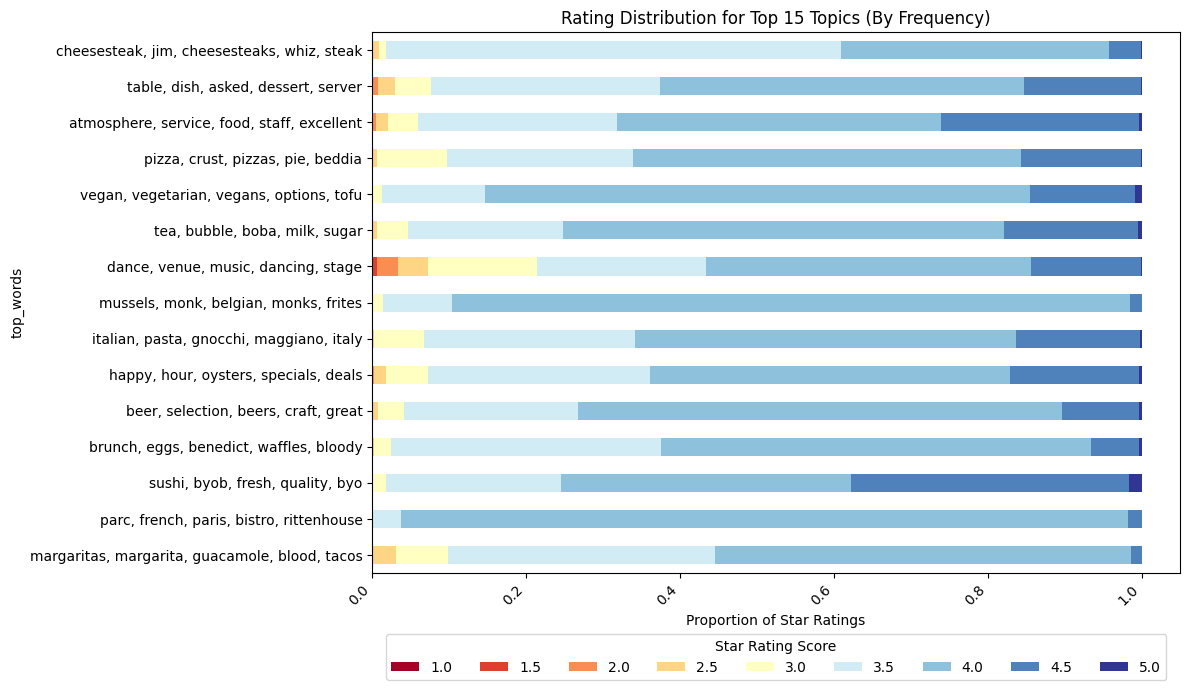

In [20]:
# Distribution of rating for previous visualization
rating_distribution = filtered_df[filtered_df['topic'].isin(top_topic_values['topic'])]

# Build counts for each rating per topic
stacked_values = rating_distribution.groupby(['top_words', 'stars']).size().unstack(fill_value=0)

# Normalize for percentage & reorder values on the basis of frequency
stacked_percent = stacked_values.div(stacked_values.sum(axis=1), axis=0)
stacked_percent = stacked_percent.reindex(top_topic_values['top_words']).iloc[::-1]

# Create graph
stacked_percent.plot(kind='barh', stacked=True, figsize=(12, 7), colormap='RdYlBu')
plt.xlabel("Proportion of Star Ratings")
plt.title("Rating Distribution for Top 15 Topics (By Frequency)")
legend = plt.legend(
    title='Star Rating Score',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=9,
    frameon=True
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Show the top 15 topics with the largest average star ratings, ranked in descending order.  

In [21]:
filtered_df.groupby('topic')['stars'].mean().sort_values(ascending=False)[0:15]

,stars
topic,
154,4.979592
205,4.684615
220,4.500000
225,4.500000
276,4.500000
570,4.500000
596,4.500000
517,4.500000
666,4.500000


This dual-axis chart underscores the top 15 topics by average rating together with their review frequencies. The light blue bars represent the average star rating for every topic, sorted in descending order The dark grey line overlays the number of reviews related to every topic on a secondary y-axis. This visualization is beneficial for finding out the high-rated niche topics that may not have many reviews, as well as identifying topics that are both well-loved and relatively popular.

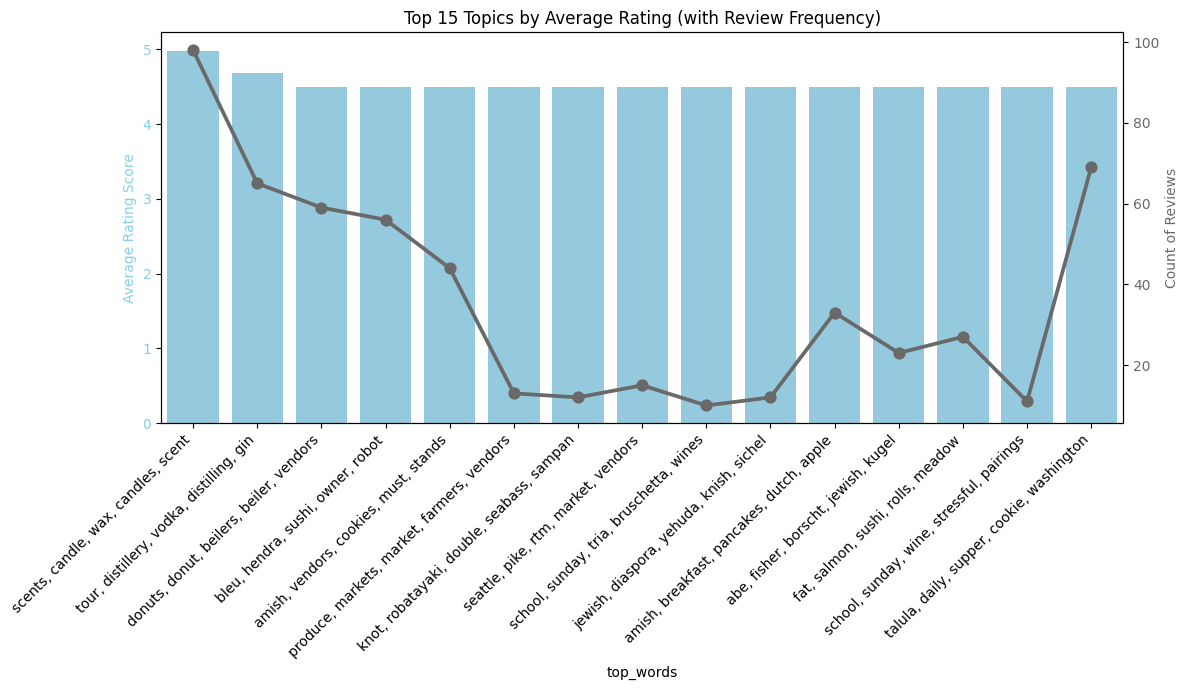

In [22]:
# Group topics
topic_grouped = filtered_df.groupby('topic').agg(
    count=('topic', 'count'),
    avg_rating=('stars', 'mean'),
    top_words=('top_words', 'first')
).reset_index()

# Obtain top 15 topics on the basis on average rating
top_rating_values = topic_grouped.sort_values(by='avg_rating', ascending=False).head(15)

# Plot average rating as well as relative frequency
fig, ax1 = plt.subplots(figsize=(12,7))

# Have axis for average rating & x-axis for topics. Add second axis for frequency
sns.barplot(x='top_words', y='avg_rating', data=top_rating_values, ax=ax1, color='skyblue')
ax1.set_ylabel('Average Rating Score', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax2 = ax1.twinx()
sns.pointplot(x='top_words', y='count', data=top_rating_values, ax=ax2, color='dimgrey', markers='o')
ax2.set_ylabel('Count of Reviews', color='dimgrey')
ax2.tick_params(axis='y', labelcolor='dimgrey')
plt.title("Top 15 Topics by Average Rating (with Review Frequency)")
plt.tight_layout()
plt.show()

Show the top 15 topics with the smallest average star ratings, ranked in ascending order.  

In [23]:
filtered_df.groupby('topic')['stars'].mean().sort_values(ascending=True)[0:15]

,stars
topic,
344,2.048387
503,2.187500
178,2.415663
328,2.442857
476,2.500000
251,2.540816
431,2.666667
119,2.723881
188,2.810811


This chart shows the bottom 15 topics by average rating and compares them against their review frequencies. The light blue bars show the average star ratings for each topic, organized in ascending order. The dark grey line is representative of the number of reviews for every topic on a secondary y-axis. This dual-axis visualization underscores which low-rated topics are also widely discussed—potentially indicating recurring problems or dissatisfaction.

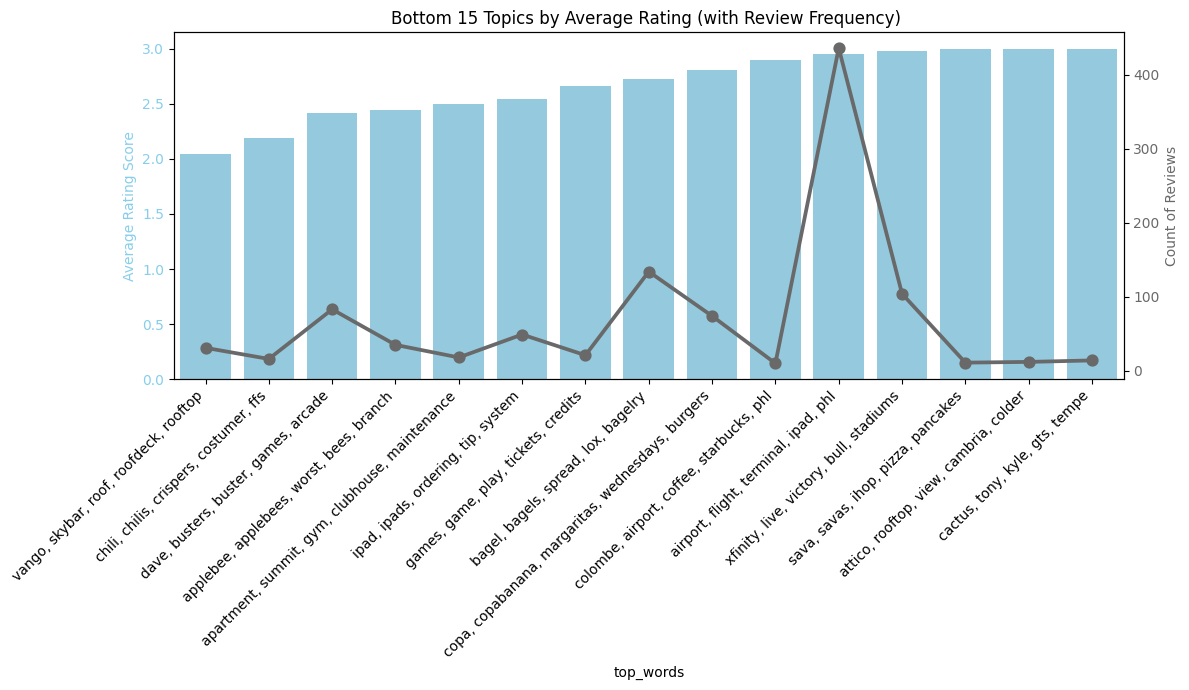

In [24]:
# Group topics
topic_grouped = filtered_df.groupby('topic').agg(
    count=('topic', 'count'),
    avg_rating=('stars', 'mean'),
    top_words=('top_words', 'first')
).reset_index()

# Obtain bottom 15 topics on the basis on average rating
top_rating_values = topic_grouped.sort_values(by='avg_rating', ascending=True).head(15)

# Plot average rating as well as relative frequency
fig, ax1 = plt.subplots(figsize=(12,7))

# Have axis for average rating & x-axis for topics. Add second axis for frequency
sns.barplot(x='top_words', y='avg_rating', data=top_rating_values, ax=ax1, color='skyblue')
ax1.set_ylabel('Average Rating Score', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax2 = ax1.twinx()
sns.pointplot(x='top_words', y='count', data=top_rating_values, ax=ax2, color='dimgrey', markers='o')
ax2.set_ylabel('Count of Reviews', color='dimgrey')
ax2.tick_params(axis='y', labelcolor='dimgrey')
plt.title("Bottom 15 Topics by Average Rating (with Review Frequency) ")
plt.tight_layout()
plt.show()

This scatterplot looks at the relationship between topic frequency (measured by count of reviews) as well as average star rating. Every point is representative of a topic, with bubble size suggesting how often the topic comes up and color intensity reflecting its average rating. A dashed black regression line has been added to observe the overall trend. Although the line suggests a slight positive correlation—indicating that more frequently mentioned topics tend to have marginally higher ratings—the scatter remains widely dispersed. This shows that high volume doesn't necessarily equate to better perception, underscoring the need to analyze both quality and popularity.

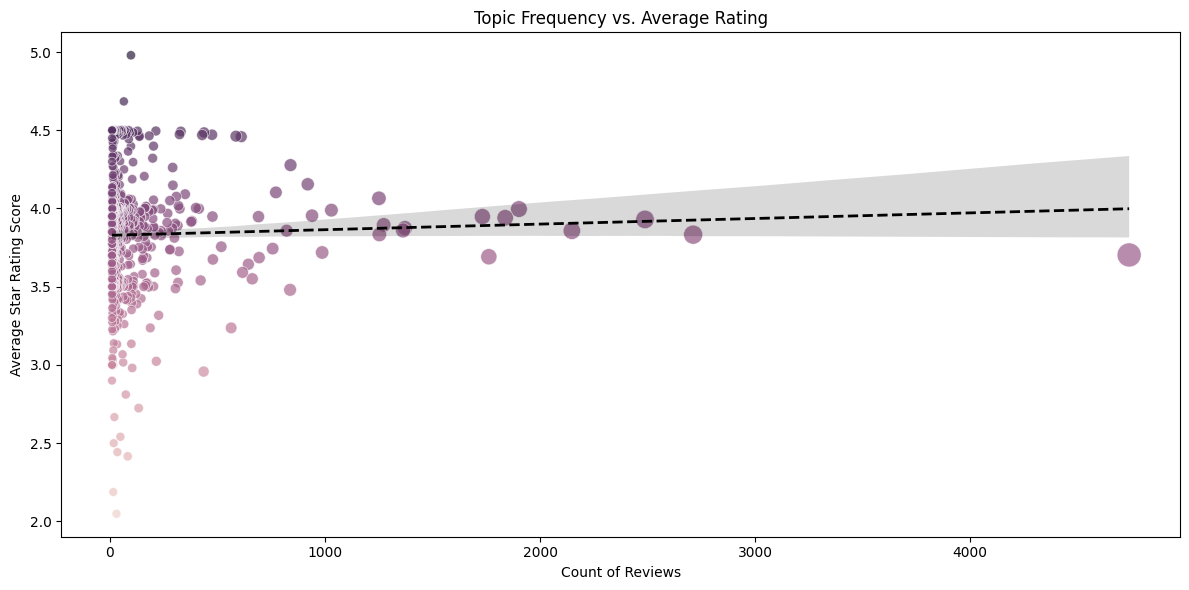

In [25]:
# Make scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=topic_grouped,
    x='count',
    y='avg_rating',
    hue='avg_rating',
    size='count',
    sizes=(40, 300),
    alpha=0.7,
    legend=False
)

# Add trend line
sns.regplot(
    data=topic_grouped,
    x='count',
    y='avg_rating',
    scatter=False,
    color='k',
    line_kws={"linewidth": 2, "linestyle": "dashed"}
)

# Add labels and adjust layout
plt.title("Topic Frequency vs. Average Rating")
plt.xlabel("Count of Reviews")
plt.ylabel("Average Star Rating Score")
plt.tight_layout()
plt.show()


This histogram visualizes the distribution of average star rating scores amongst all identified topics. A lot of the topics have an average rating clustered between 3.5 and 4.0, as seen from the peak in the center of the distribution. The inclusion of a KDE (kernel density estimate) line overlays a smoothed curve, implying a slight right skew, suggesting a few topics are rated particularly highly. In contrast, topics with very low or very high average ratings are comparatively rare. As a whole, this visualization shows that most topics tend to be rated favorably, though perfect or very poor scores are not common.

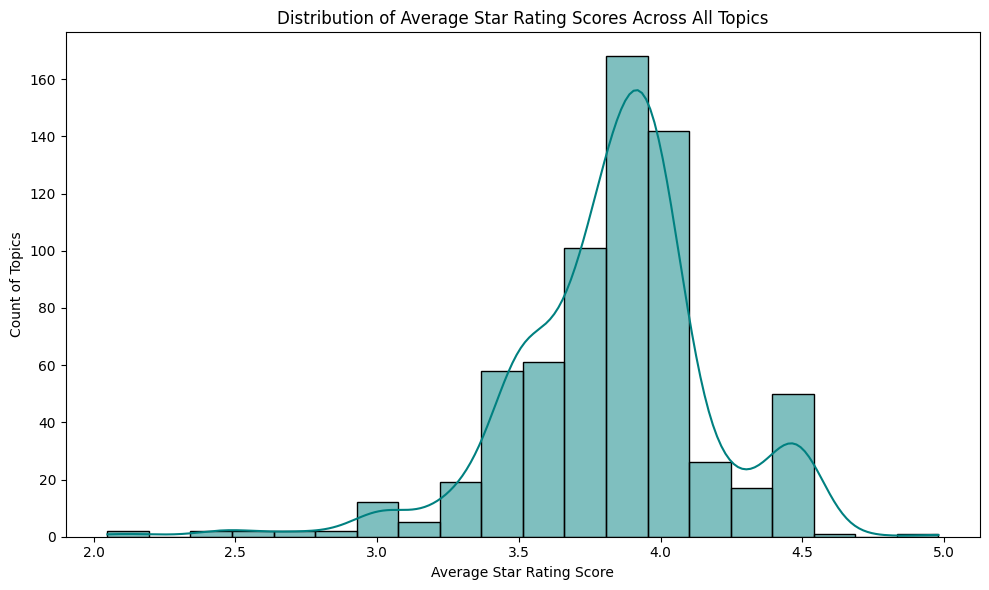

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(topic_grouped['avg_rating'], bins=20, kde=True, color='teal')
plt.title("Distribution of Average Star Rating Scores Across All Topics")
plt.xlabel("Average Star Rating Score")
plt.ylabel("Count of Topics")
plt.tight_layout()
plt.show()

### Topic Modeling Insights Summary

This analysis evaluated which types of bars are most successful by comparing BERTopic-derived themes with average star ratings and review frequencies. A lot of the topics clustered between 3.5 and 4.2 stars, implying generally favorable customer sentiment. Bars that focused on good service, ambiance, and food quality such as those tied to “atmosphere, service, food” consistently obtained higher ratings.

Food-forward bar themes like sushi stood out for receiving both high frequency and high average ratings, implying that customers like bars offering distinctive, high-quality food alongside drinks. Other successful themes consisted of vegan-friendly bars, implying rising appeal for niche experiences.

On the other hand, nightlife-driven and novelty-oriented bars (e.g., rooftops, dance venues, tech-based ordering) often underperformed. These bars received attention but were rated poorly, suggesting that style alone does not compensate for bad service or execution. The weak correlation between frequency and rating further suggests that success is more reliant on quality and consistency than popularity.

## Checking Topic Modelling (Part 2)

Manually labeled topics for a small subset of the data were used to check that the topic modeling was done appropriately. Only 50 reviews were manually labeled, because this process is time-intensive and the objective was to evaluate interpretability rather than perform statistical correlation. Beyond the limited sample size, topics are inherently qualitative and individualized, making them unsuitable for valuable correlation analysis. Instead, the effectiveness and relevance of the assigned labels were manually assessed, and this sample was sufficient to validate that the generated topics were logical and appropriate.

In [44]:
manual_df = filtered_df[['text']].sample(n=50, random_state=42)
manual_df.to_csv("hand_label.csv", index=True)

In [45]:
updated_manual_df = pd.read_csv("updated_hand_label.csv", encoding='ISO-8859-1')
print(updated_manual_df)

    Unnamed: 0                                               text  \
0       189083  The food is fantastic! Great cocktails. The se...   
1       166501  Hip and cool.  Almost too much of both.  Expen...   
2       166144  Ordered through Uber eats.\n\nHummus: it's cre...   
3       164657  Went on the Big Red Pedal Tours with some frie...   
4        48298  LOVE Tir na nog! Stumbled upon this place whil...   
5       126867  This is the place just to go for experience. T...   
6        32111  Parc was recommend by a friend in which he sta...   
7       170960  Nice hotel but the night front desk lady over ...   
8        78797  I always go back to Jim's on South Street to h...   
9        95580  Was visiting from out of town, so got a few fr...   
10       18929  Revolution is not my favorite place in the cit...   
11      141957  The second stop on the vegan cheesesteak tour ...   
12       63006  I decided I needed a juice cleanse after spend...   
13       60887  Great food great s

Let us combine the manual topic words and the derived topic words

In [46]:
merged_dataframe= updated_manual_df.merge(filtered_df[['text', 'topic', 'top_words']], on='text', how='left')
merged_dataframe

,Unnamed: 0,text,topic_hand,topic,top_words
0,189083,The food is fantastic! Great cocktails. The se...,"food, attentive, cocktails, fantastic, amazing",153.0,"cocktails, cocktail, atmosphere, specialty, am..."
1,166501,Hip and cool. Almost too much of both. Expen...,"hip, cool, photos, visit, expensive",325.0,"philly, visit, pub, pongin, liftin"
2,166144,Ordered through Uber eats.\n\nHummus: it's cre...,"hummus, flavor, eats, baba, chickpea",56.0,"hummus, pita, cauliflower, turkish, lamb"
3,164657,Went on the Big Red Pedal Tours with some frie...,"tours, great, weekend",234.0,"pedal, tour, bike, guides, tours"
4,48298,LOVE Tir na nog! Stumbled upon this place whil...,"irish, trip, slow, chips, tir na nog, friendly",37.0,"irish, pub, guinness, fergie, paddy"
5,126867,This is the place just to go for experience. T...,"experience, complemented, pricier, able, bottl...",20.0,"wine, wines, glass, jet, flights"
6,32111,Parc was recommend by a friend in which he sta...,"friend, parc, rare, recovery, refunded",13.0,"parc, french, paris, bistro, rittenhouse"
7,170960,Nice hotel but the night front desk lady over ...,"desk, wig, terrible, stank, hotel",26.0,"hotel, sofitel, room, bed, stay"
8,78797,I always go back to Jim's on South Street to h...,"jim, cheesesteak, long, waiting, whiz",0.0,"cheesesteak, jim, cheesesteaks, whiz, steak"
9,95580,"Was visiting from out of town, so got a few fr...","wagyu, hotpot, spicy, cattle",27.0,"pot, wagyu, chubby, hotpot, cattle"


In [47]:
merged_dataframe.to_csv('merged_dataframe.csv', index=False)

### Conclusion

To check the interpretability and alignment of our topic modeling outcomes, we manually labeled a sample of reviews with human-readable topic descriptions and compared them against the model-derived top words from BERTopic. The comparison provided us with strong thematic overlap in many cases. The word choices are not always the same, but topics related to service quality, food type, atmosphere, and drink options were often identified through both manual intuition and the unsupervised model.

Even though there were cases where the phrasing or specific keywords differed, and a few instances where the underlying themes did not match as much, the main ideas were generally well-aligned. This implies that BERTopic can be beneficial for creating interpretable and meaningful groupings that reflect much of the content in customer reviews. This practice also confirmed the model’s potential for summarizing large volumes of text in a way that can broadly support human understanding.

Overall, the observed consistency between human and model interpretation in many cases provides support for the value of BERTopic for exploratory text analysis. However, as with any unsupervised technique, there remains a risk of incoherent or inaccurate topic groupings, which underscores the value of human validation.